In [177]:
import warnings
warnings.filterwarnings('ignore')
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\skana\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\skana\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\skana\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\skana\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [178]:
df=pd.read_csv('kddcup99_csv.csv')

In [179]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal
1,0,tcp,http,SF,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal
2,0,tcp,http,SF,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal
3,0,tcp,http,SF,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal
4,0,tcp,http,SF,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal


In [180]:
df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'lnum_compromised', 'lroot_shell',
       'lsu_attempted', 'lnum_root', 'lnum_file_creations', 'lnum_shells',
       'lnum_access_files', 'lnum_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label'],
      dtype='str')

In [181]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 494020 entries, 0 to 494019
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494020 non-null  int64  
 1   protocol_type                494020 non-null  str    
 2   service                      494020 non-null  str    
 3   flag                         494020 non-null  str    
 4   src_bytes                    494020 non-null  int64  
 5   dst_bytes                    494020 non-null  int64  
 6   land                         494020 non-null  int64  
 7   wrong_fragment               494020 non-null  int64  
 8   urgent                       494020 non-null  int64  
 9   hot                          494020 non-null  int64  
 10  num_failed_logins            494020 non-null  int64  
 11  logged_in                    494020 non-null  int64  
 12  lnum_compromised             494020 non-null  int64  
 13  lroot_shel

In [182]:
df.shape

(494020, 42)

In [183]:
df.isna().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
lnum_compromised               0
lroot_shell                    0
lsu_attempted                  0
lnum_root                      0
lnum_file_creations            0
lnum_shells                    0
lnum_access_files              0
lnum_outbound_cmds             0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

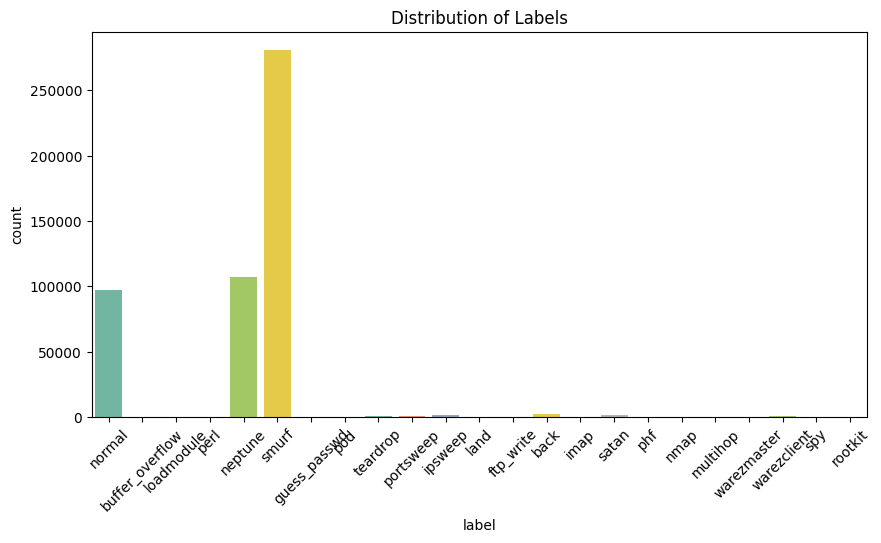

In [184]:
plt.figure(figsize=(10,5))
sns.countplot(x='label', data=df, palette='Set2')
plt.title('Distribution of Labels')
plt.xticks(rotation=45)
plt.show()


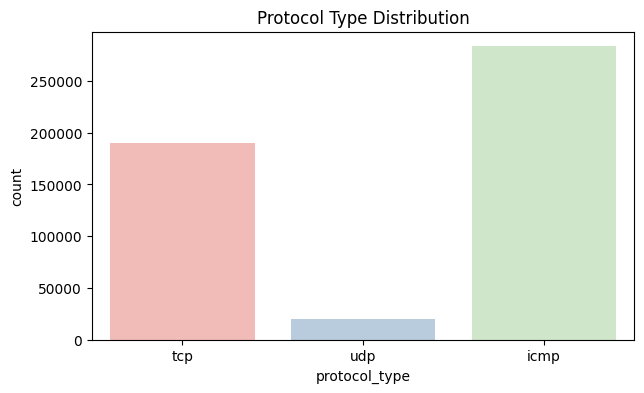

In [185]:
plt.figure(figsize=(7,4))
sns.countplot(x='protocol_type', data=df, palette='Pastel1')
plt.title('Protocol Type Distribution')
plt.show()


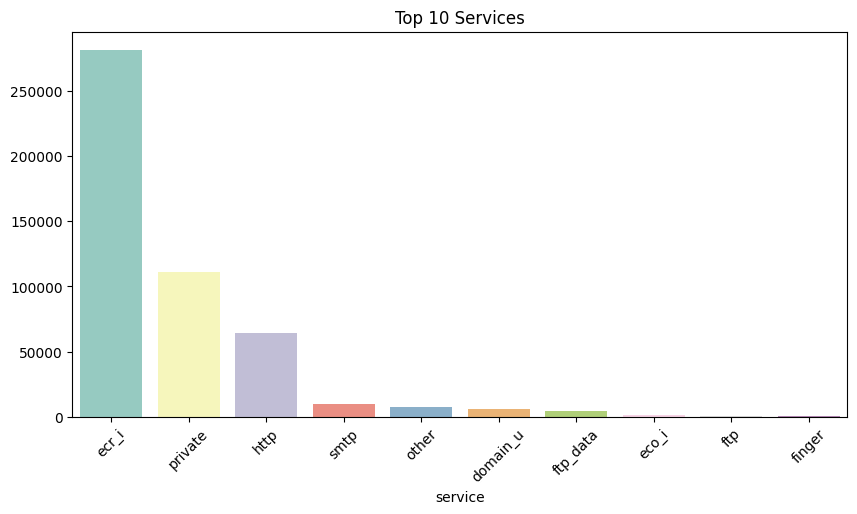

In [186]:
top_services = df['service'].value_counts().nlargest(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_services.index, y=top_services.values, palette='Set3')
plt.title("Top 10 Services")
plt.xticks(rotation=45)
plt.show()


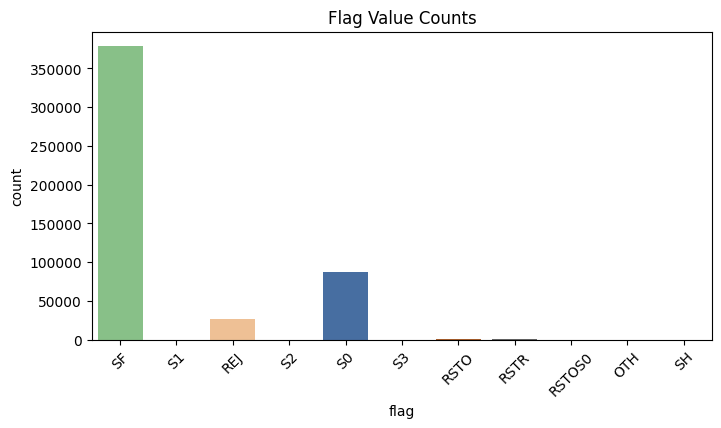

In [187]:
plt.figure(figsize=(8,4))
sns.countplot(x='flag', data=df, palette='Accent')
plt.title('Flag Value Counts')
plt.xticks(rotation=45)
plt.show()


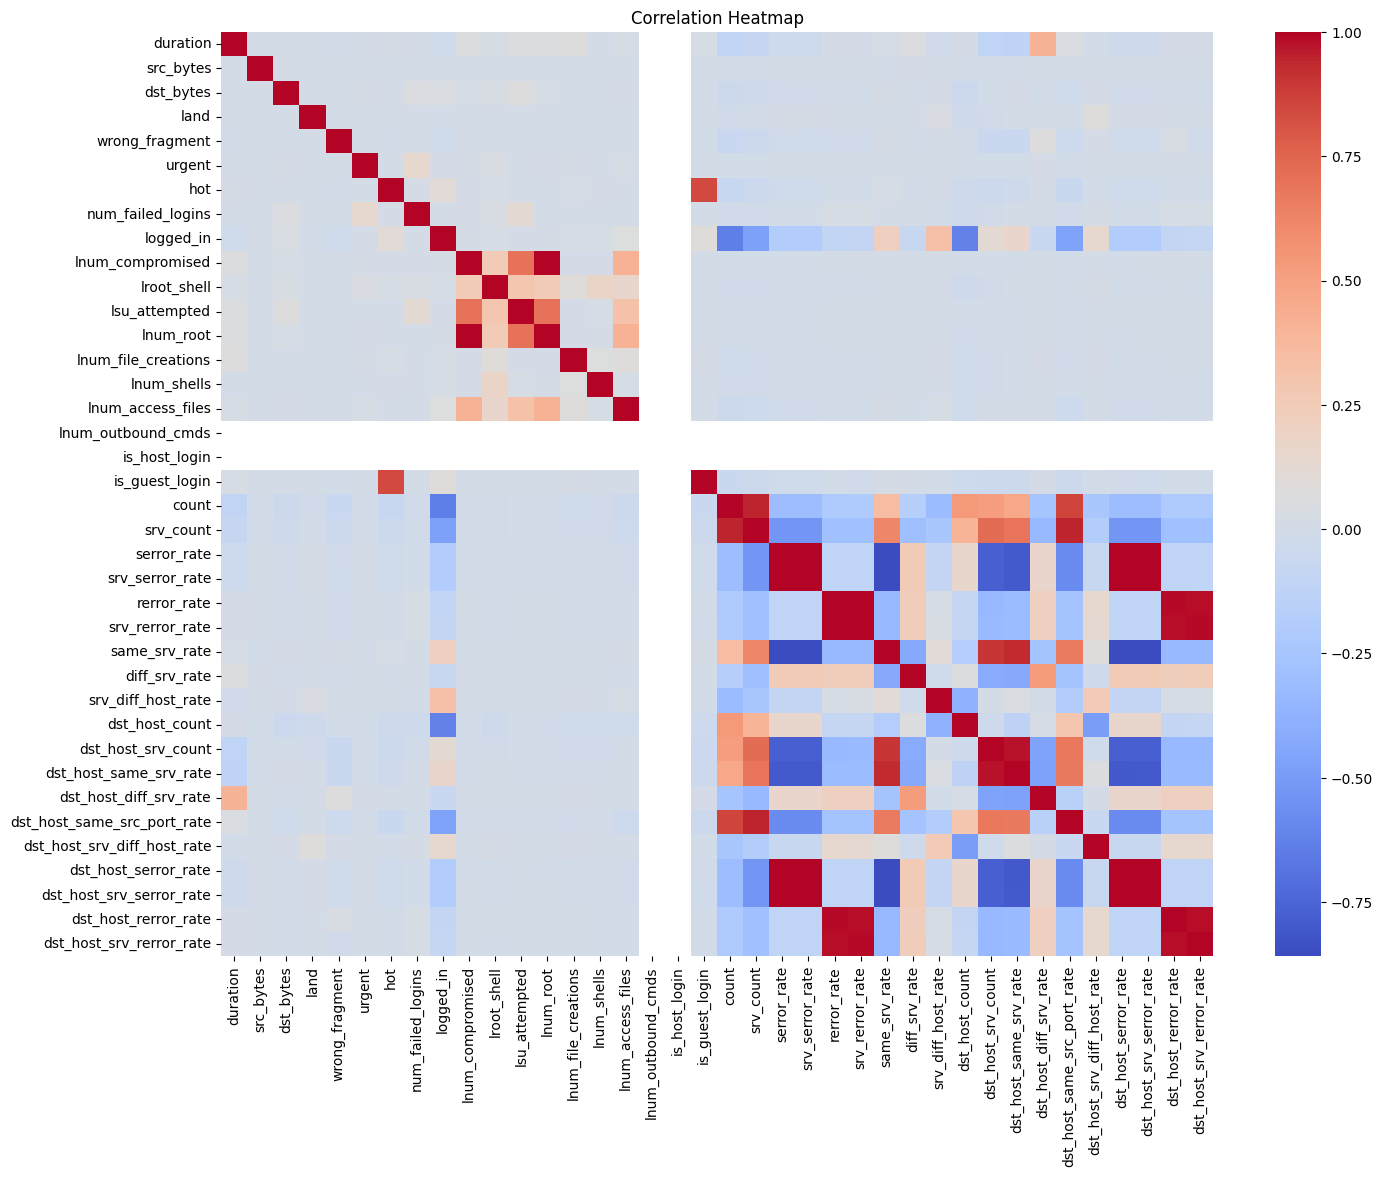

In [188]:
plt.figure(figsize=(16,12))
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation = df[numeric_cols].corr()
sns.heatmap(correlation, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()


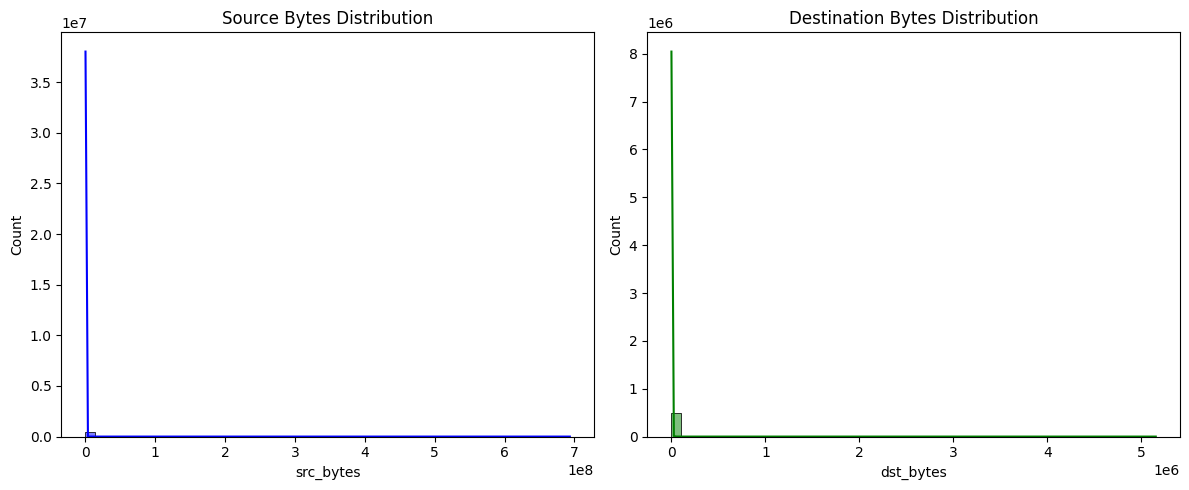

In [189]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['src_bytes'], bins=50, kde=True, color='blue')
plt.title('Source Bytes Distribution')

plt.subplot(1,2,2)
sns.histplot(df['dst_bytes'], bins=50, kde=True, color='green')
plt.title('Destination Bytes Distribution')
plt.tight_layout()
plt.show()


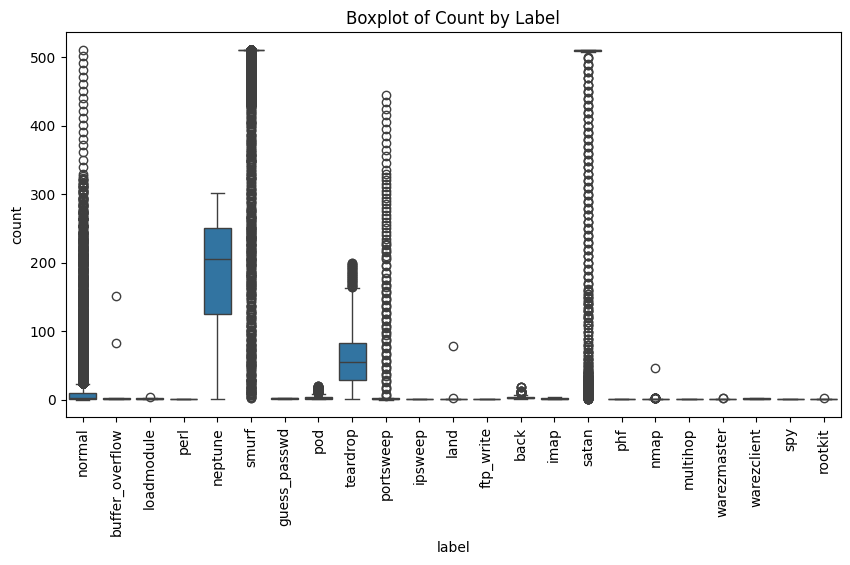

In [190]:
plt.figure(figsize=(10,5))
sns.boxplot(x='label', y='count', data=df)
plt.title('Boxplot of Count by Label')
plt.xticks(rotation=90)
plt.show()


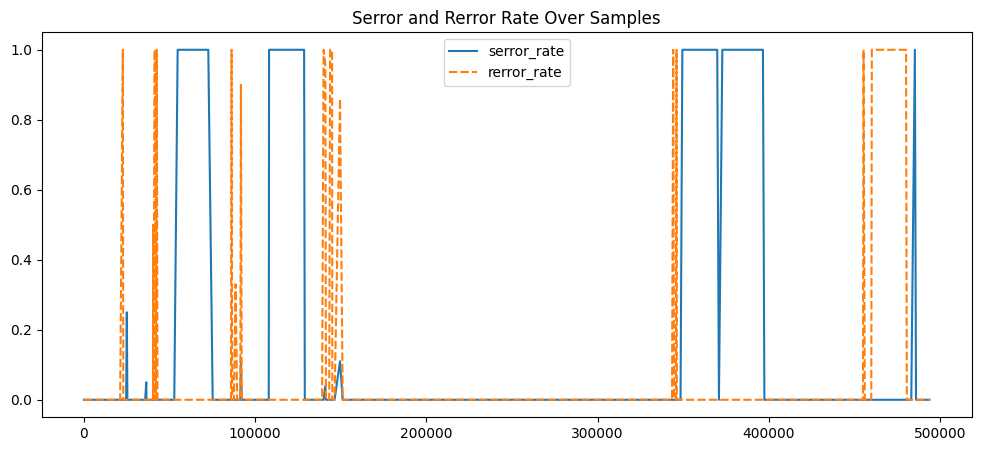

In [191]:
df_sample = df.sample(1000)  # to reduce overload
plt.figure(figsize=(12,5))
sns.lineplot(data=df_sample[['serror_rate', 'rerror_rate']])
plt.title('Serror and Rerror Rate Over Samples')
plt.show()


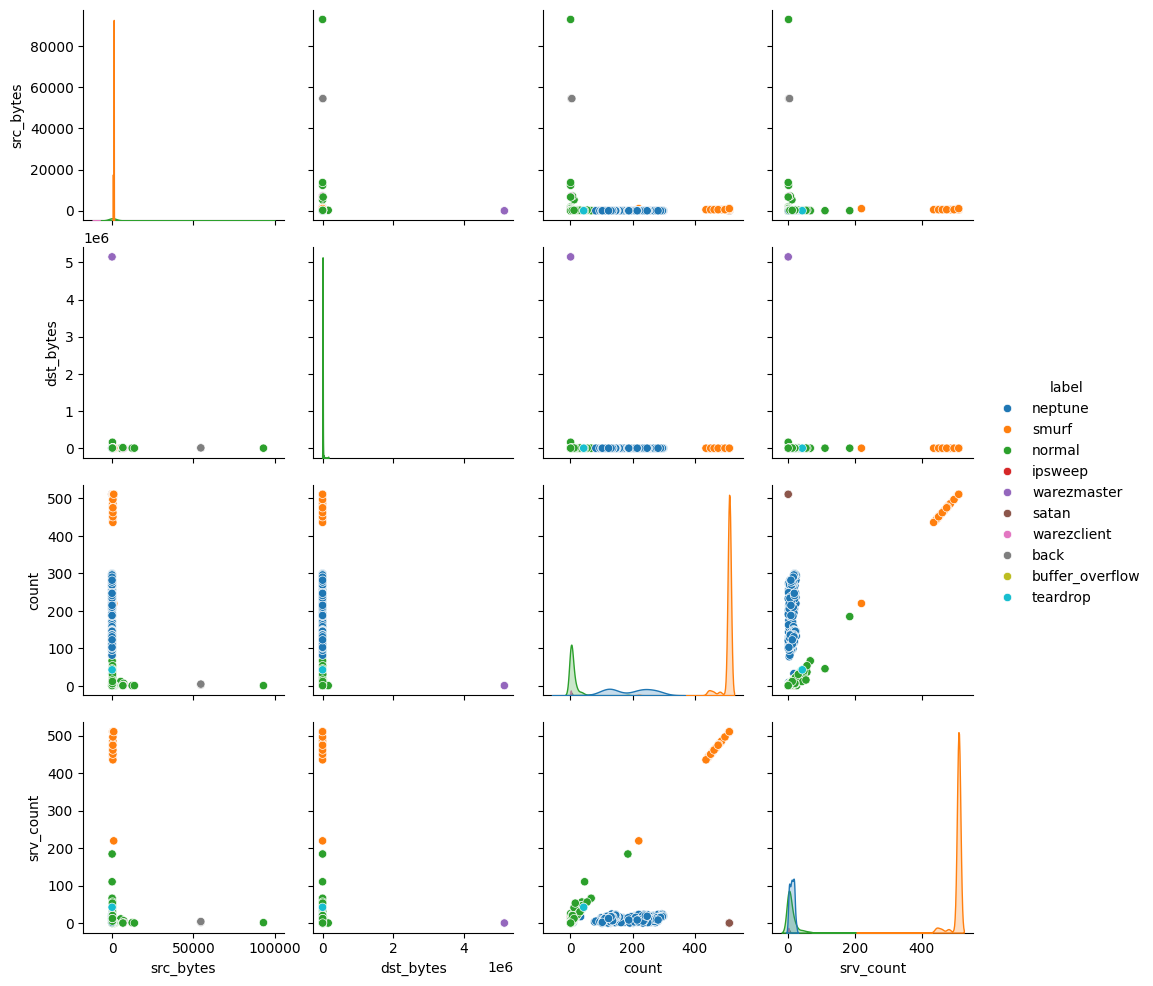

In [192]:
df_sample = df[['src_bytes', 'dst_bytes', 'count', 'srv_count', 'label']].sample(1000)
sns.pairplot(df_sample, hue='label')
plt.show()


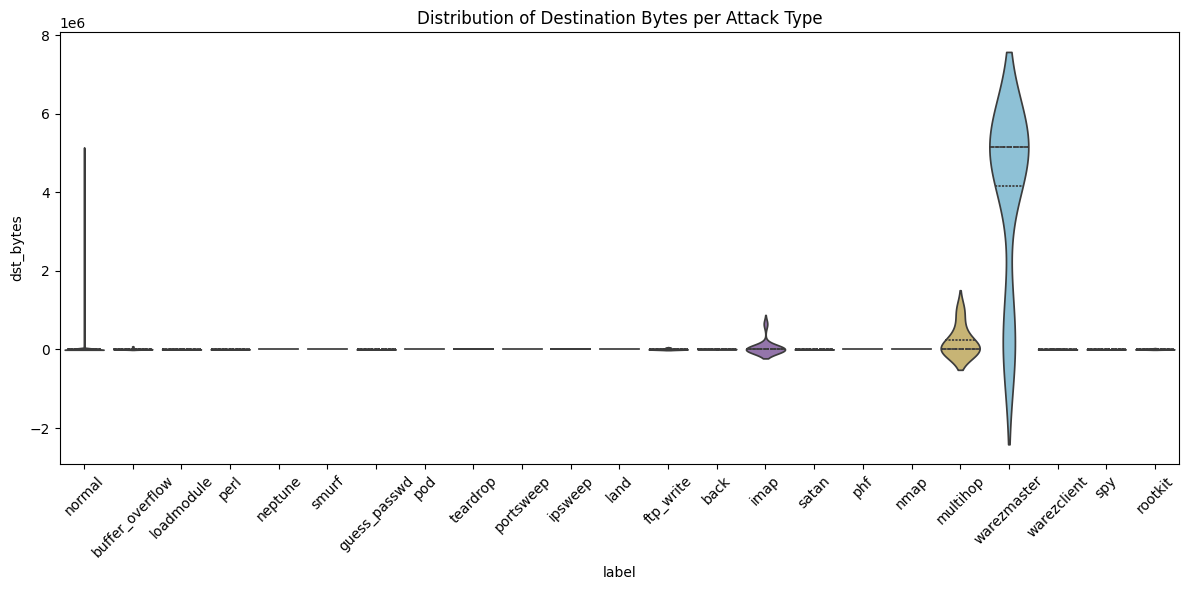

In [193]:
plt.figure(figsize=(12,6))
sns.violinplot(x='label', y='dst_bytes', data=df, scale='width', inner='quartile', palette='muted')
plt.title('Distribution of Destination Bytes per Attack Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


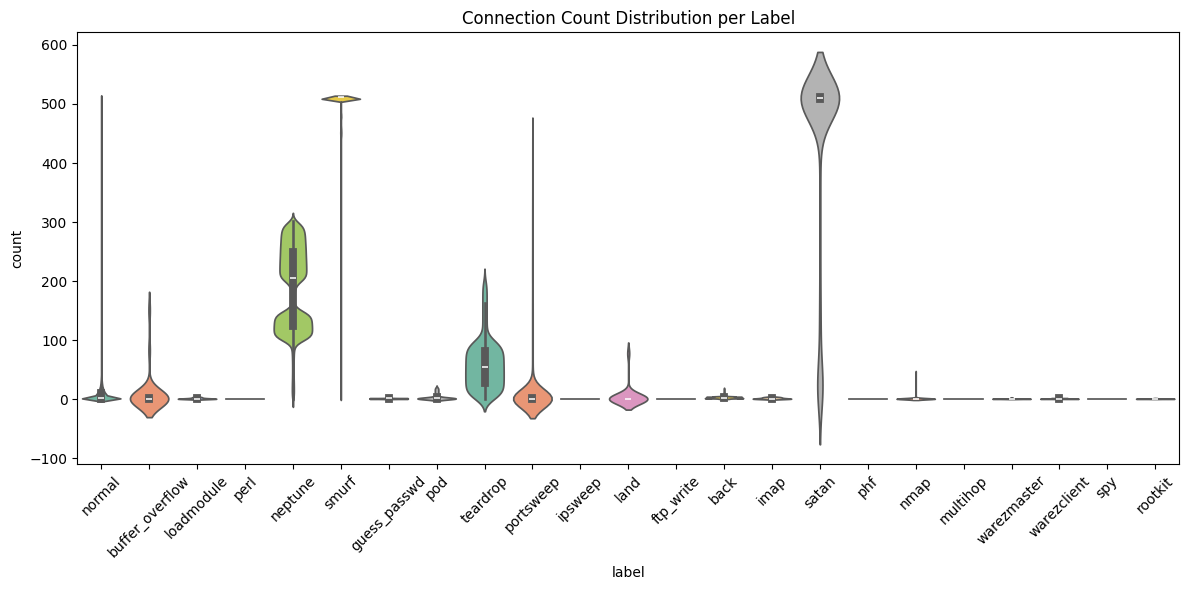

In [194]:
plt.figure(figsize=(12,6))
sns.violinplot(x='label', y='count', data=df, scale='width', inner='box', palette='Set2')
plt.title('Connection Count Distribution per Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


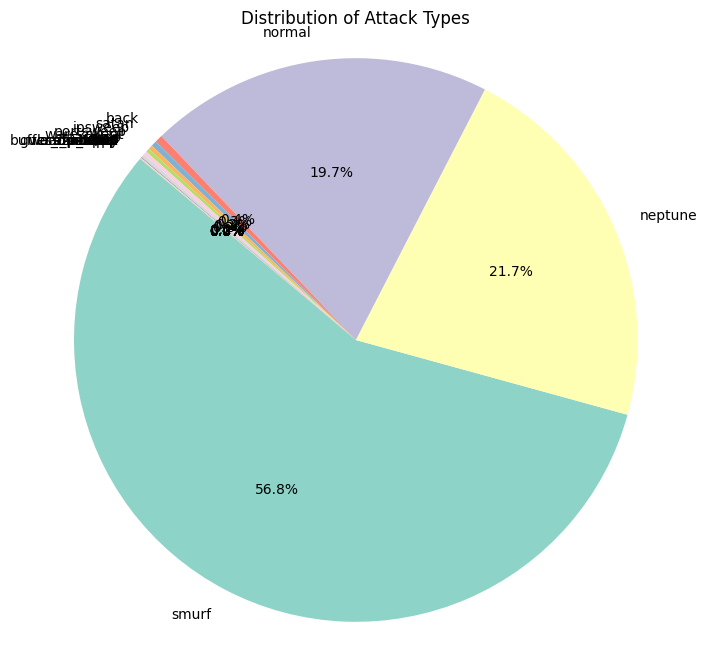

In [195]:
plt.figure(figsize=(8,8))
label_counts = df['label'].value_counts()

plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Set3.colors)
plt.title('Distribution of Attack Types')
plt.axis('equal')  # Equal aspect ratio to ensure pie is circular
plt.show()

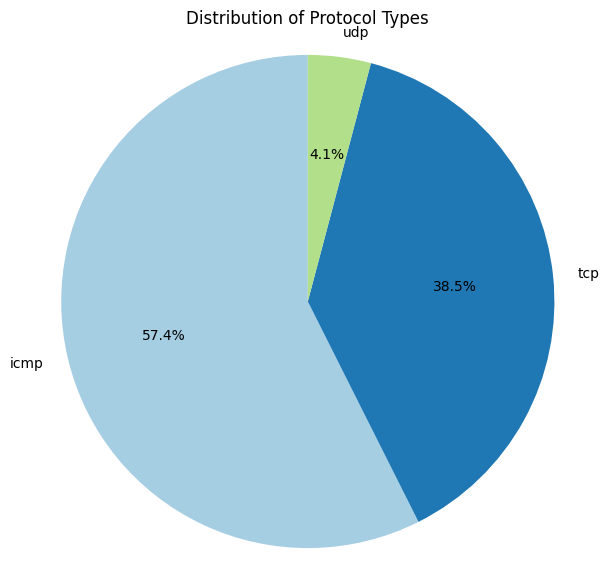

In [196]:
protocol_counts = df['protocol_type'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(protocol_counts, labels=protocol_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('Distribution of Protocol Types')
plt.axis('equal')
plt.show()


In [197]:
print('Data set:')
for col_name in df.columns:
    if df[col_name].dtypes == 'object' :
        unique_cat = len(df[col_name].unique())
        print("Feature '{col_name}' has {unique_cat} categories".format(col_name=col_name, unique_cat=unique_cat))

print()
print('Distribution of categories in service:')
print(df['service'].value_counts().sort_values(ascending=False).head())

Data set:

Distribution of categories in service:
service
ecr_i      281400
private    110893
http        64292
smtp         9723
other        7237
Name: count, dtype: int64


In [198]:
df['flag'].unique() 

<StringArray>
['SF', 'S1', 'REJ', 'S2', 'S0', 'S3', 'RSTO', 'RSTR', 'RSTOS0', 'OTH', 'SH']
Length: 11, dtype: str

In [199]:
flag_mapping = {
    'SF': 0,
    'S1': 1,
    'REJ': 2,
    'S2': 3,
    'S0': 4,
    'S3': 5,
    'RSTO': 6,
    'RSTR': 7,
    'RSTOS0': 8,
    'OTH': 9,
    'SH': 10
}


In [200]:
df['flag'] = df['flag'].map(flag_mapping)

In [201]:
df['service'].unique()

<StringArray>
[       'http',        'smtp',      'finger',    'domain_u',        'auth',
      'telnet',         'ftp',       'eco_i',       'ntp_u',       'ecr_i',
       'other',     'private',       'pop_3',    'ftp_data',         'rje',
        'time',         'mtp',        'link',  'remote_job',      'gopher',
         'ssh',        'name',       'whois',      'domain',       'login',
       'imap4',     'daytime',         'ctf',        'nntp',       'shell',
         'IRC',        'nnsp',    'http_443',        'exec',     'printer',
         'efs',     'courier',        'uucp',      'klogin',      'kshell',
        'echo',     'discard',      'systat',      'supdup',    'iso_tsap',
   'hostnames',    'csnet_ns',       'pop_2',      'sunrpc',   'uucp_path',
  'netbios_ns', 'netbios_ssn', 'netbios_dgm',     'sql_net',       'vmnet',
         'bgp',      'Z39_50',        'ldap',     'netstat',       'urh_i',
         'X11',       'urp_i',     'pm_dump',      'tftp_u',       'tim_i'

In [202]:
service_mapping = {
    'http': 0,
    'smtp': 1,
    'finger': 2,
    'domain_u': 3,
    'auth': 4,
    'telnet': 5,
    'ftp': 6,
    'eco_i': 7,
    'ntp_u': 8,
    'ecr_i': 9,
    'other': 10,
    'private': 11,
    'pop_3': 12,
    'ftp_data': 13,
    'rje': 14,
    'time': 15,
    'mtp': 16,
    'link': 17,
    'remote_job': 18,
    'gopher': 19,
    'ssh': 20,
    'name': 21,
    'whois': 22,
    'domain': 23,
    'login': 24,
    'imap4': 25,
    'daytime': 26,
    'ctf': 27,
    'nntp': 28,
    'shell': 29,
    'IRC': 30,
    'nnsp': 31,
    'http_443': 32,
    'exec': 33,
    'printer': 34,
    'efs': 35,
    'courier': 36,
    'uucp': 37,
    'klogin': 38,
    'kshell': 39,
    'echo': 40,
    'discard': 41,
    'systat': 42,
    'supdup': 43,
    'iso_tsap': 44,
    'hostnames': 45,
    'csnet_ns': 46,
    'pop_2': 47,
    'sunrpc': 48,
    'uucp_path': 49,
    'netbios_ns': 50,
    'netbios_ssn': 51,
    'netbios_dgm': 52,
    'sql_net': 53,
    'vmnet': 54,
    'bgp': 55,
    'Z39_50': 56,
    'ldap': 57,
    'netstat': 58,
    'urh_i': 59,
    'X11': 60,
    'urp_i': 61,
    'pm_dump': 62,
    'tftp_u': 63,
    'tim_i': 64,
    'red_i': 65
}


In [203]:
df['service'] = df['service'].map(service_mapping)

In [204]:
df['protocol_type'].unique()

<StringArray>
['tcp', 'udp', 'icmp']
Length: 3, dtype: str

In [205]:
protocol_type_mapping = {
    'tcp': 0,
    'udp': 1,
    'icmp': 2
}

In [206]:
df['protocol_type'] = df['protocol_type'].map(protocol_type_mapping)

In [207]:
df['flag'].unique() 

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [208]:
df['service'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65])

In [209]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,0,0,0,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal
1,0,0,0,0,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal
2,0,0,0,0,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal
3,0,0,0,0,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal
4,0,0,0,0,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal


In [210]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 494020 entries, 0 to 494019
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494020 non-null  int64  
 1   protocol_type                494020 non-null  int64  
 2   service                      494020 non-null  int64  
 3   flag                         494020 non-null  int64  
 4   src_bytes                    494020 non-null  int64  
 5   dst_bytes                    494020 non-null  int64  
 6   land                         494020 non-null  int64  
 7   wrong_fragment               494020 non-null  int64  
 8   urgent                       494020 non-null  int64  
 9   hot                          494020 non-null  int64  
 10  num_failed_logins            494020 non-null  int64  
 11  logged_in                    494020 non-null  int64  
 12  lnum_compromised             494020 non-null  int64  
 13  lroot_shel

### Rename all label: 0=normal, 1=DoS, 2=Probe, R2L and U2R.

DOS: denial-of-service, e.g. syn flood;
R2L: unauthorized access from a remote machine, e.g. guessing password;
U2R: unauthorized access to local superuser (root) privileges, e.g., various ``buffer overflow’’ attacks;
probing: surveillance and other probing, e.g., port scanning.

In [211]:
df1=df['label']

In [212]:
print('Label distribution Training set:')
print(df['label'].value_counts())

Label distribution Training set:
label
smurf              280790
neptune            107201
normal              97277
back                 2203
satan                1589
ipsweep              1247
portsweep            1040
warezclient          1020
teardrop              979
pod                   264
nmap                  231
guess_passwd           53
buffer_overflow        30
land                   21
warezmaster            20
imap                   12
rootkit                10
loadmodule              9
ftp_write               8
multihop                7
phf                     4
perl                    3
spy                     2
Name: count, dtype: int64


In [213]:
newdf=df1.replace({'normal':0,'smurf':1,'neptune':1,'back':1,'satan':2,'ipsweep':2,'portsweep':2,'warezclient': 2,'teardrop': 1,
                  'pod': 1,'nmap' : 2,'guess_passwd': 2,'buffer_overflow': 2,'land': 1,'warezmaster': 2,'imap': 2,'rootkit': 2,
                  'loadmodule': 2,'ftp_write': 2,'multihop': 2,'phf': 2,'perl': 2,'spy': 2})

In [214]:
print(newdf.head())
#newdf.to_csv('label.csv')

0    0
1    0
2    0
3    0
4    0
Name: label, dtype: object


In [215]:
df['label'] = newdf
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,0,0,0,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,0
1,0,0,0,0,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,0
2,0,0,0,0,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,0
3,0,0,0,0,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,0
4,0,0,0,0,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,0


In [216]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 494020 entries, 0 to 494019
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494020 non-null  int64  
 1   protocol_type                494020 non-null  int64  
 2   service                      494020 non-null  int64  
 3   flag                         494020 non-null  int64  
 4   src_bytes                    494020 non-null  int64  
 5   dst_bytes                    494020 non-null  int64  
 6   land                         494020 non-null  int64  
 7   wrong_fragment               494020 non-null  int64  
 8   urgent                       494020 non-null  int64  
 9   hot                          494020 non-null  int64  
 10  num_failed_logins            494020 non-null  int64  
 11  logged_in                    494020 non-null  int64  
 12  lnum_compromised             494020 non-null  int64  
 13  lroot_shel

<Axes: xlabel='label', ylabel='count'>

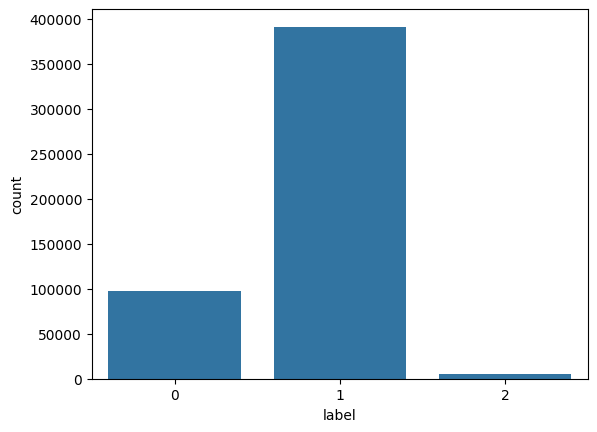

In [217]:
sns.countplot(x='label',data=df)

# Feature Selection

In [218]:
from sklearn.ensemble import ExtraTreesClassifier
model = ExtraTreesClassifier()

In [219]:
df['label'].unique()

array([0, 2, 1], dtype=object)

In [220]:
df['label'].astype(int)

0         0
1         0
2         0
3         0
4         0
         ..
494015    0
494016    0
494017    0
494018    0
494019    0
Name: label, Length: 494020, dtype: int64

In [221]:
X = df.iloc[:,df.columns!='label'] 
y = df['label'].astype(int)  

In [222]:
df['label'] .value_counts()

label
1    391458
0     97277
2      5285
Name: count, dtype: int64

In [223]:
model.fit(X,y)
print(model.feature_importances_)

[4.99738889e-04 8.50028701e-02 2.36843481e-02 5.13411297e-03
 1.03030942e-02 2.21016923e-03 4.10299259e-05 7.24982817e-03
 1.01249759e-05 1.01754304e-02 1.72380167e-04 1.62804862e-01
 5.57837426e-03 1.23295650e-04 5.40754544e-06 5.56099986e-05
 4.96604311e-05 1.86995614e-05 3.11006599e-05 0.00000000e+00
 0.00000000e+00 9.56869873e-04 1.79874730e-01 8.47274295e-02
 3.34790829e-02 2.72711779e-02 9.24101824e-03 7.00166715e-03
 4.80966836e-02 1.83033710e-02 1.20263619e-02 3.66876112e-02
 2.97036097e-02 4.41603323e-02 1.78872340e-02 5.55834268e-02
 5.61204347e-03 2.12878909e-02 2.37933041e-02 1.67893138e-02
 1.43667044e-02]


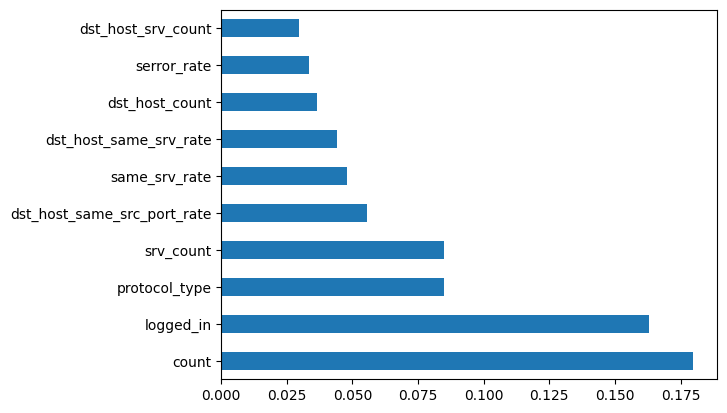

In [224]:
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

In [225]:
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest

In [226]:
bestfeatures = SelectKBest(score_func=chi2, k=10)
fit = bestfeatures.fit(X,y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)

In [227]:
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Specs','Score']  
featureScores.nlargest(10,'Score')  

,Specs,Score
4,src_bytes,6.116996e+10
5,dst_bytes,2.308604e+09
0,duration,9.867518e+07
22,count,3.954004e+07
23,srv_count,3.519352e+07
31,dst_host_count,3.922659e+06
32,dst_host_srv_count,6.381743e+05
2,service,4.630522e+05
9,hot,3.765047e+05
11,logged_in,2.675627e+05


In [228]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [229]:
xtrain, xtest, ytrain, ytest=train_test_split(X, y, test_size=0.33)

In [230]:
from sklearn.ensemble import RandomForestClassifier

In [231]:
rf=RandomForestClassifier()

In [232]:
rf.fit(xtrain,ytrain)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [233]:
predic=rf.predict(xtest)

In [234]:
acc1=accuracy_score(predic,ytest)
acc1

0.9998282493083968

In [235]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

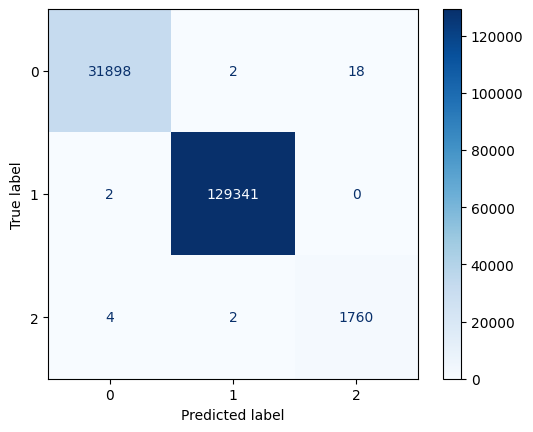

In [236]:
cm = confusion_matrix(predic,ytest)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1,2])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [237]:
clf=classification_report(predic,ytest)
print(clf)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     31918
           1       1.00      1.00      1.00    129343
           2       0.99      1.00      0.99      1766

    accuracy                           1.00    163027
   macro avg       1.00      1.00      1.00    163027
weighted avg       1.00      1.00      1.00    163027



In [238]:
xtrain.shape

(330993, 41)

In [239]:
ytrain.shape

(330993,)

In [240]:
from sklearn import svm

In [241]:
sv=svm.LinearSVC()

In [242]:
sv.fit(xtrain,ytrain)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [243]:
predic1=sv.predict(xtest)

In [244]:
acc2=accuracy_score(predic1,ytest)
acc2

0.9829046722322069

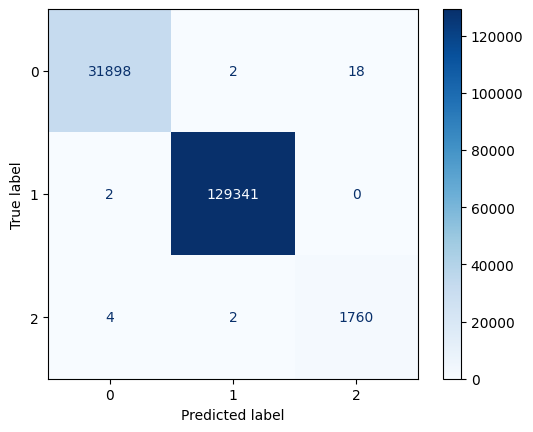

In [245]:
cm = confusion_matrix(predic,ytest)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1,2])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [246]:
clf1=classification_report(predic1,ytest)
print(clf1)

              precision    recall  f1-score   support

           0       0.99      0.95      0.97     33392
           1       0.99      0.99      0.99    129315
           2       0.12      0.66      0.20       320

    accuracy                           0.98    163027
   macro avg       0.70      0.87      0.72    163027
weighted avg       0.99      0.98      0.99    163027



In [247]:
df['label'].unique()

array([0, 2, 1], dtype=object)

In [248]:
import pickle
with open('model.pkl','wb') as file:
    pickle.dump(sv,file)